In [1]:
!pip install yfinance pandas matplotlib
import yfinance as yf
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
import yfinance as yf
amd = yf.download("AMD", start="2022-01-01", end="2026-01-01")

amd.head()

/tmp/ipykernel_38093/44557195.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amd = yf.download("AMD", start="2022-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2022-01-03,150.240005,151.649994,145.020004,145.139999,59396600
2022-01-04,144.419998,152.419998,140.699997,151.009995,80200500
2022-01-05,136.149994,143.759995,135.289993,142.820007,65403200
2022-01-06,136.229996,138.000000,131.770004,136.190002,64802900
2022-01-07,132.000000,137.440002,131.130005,136.279999,58441100


In [4]:
amd = amd.reset_index()

amd.columns = [
    "Date",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

amd.head()

,Date,Close,High,Low,Open,Volume
0,2022-01-03,150.240005,151.649994,145.020004,145.139999,59396600
1,2022-01-04,144.419998,152.419998,140.699997,151.009995,80200500
2,2022-01-05,136.149994,143.759995,135.289993,142.820007,65403200
3,2022-01-06,136.229996,138.000000,131.770004,136.190002,64802900
4,2022-01-07,132.000000,137.440002,131.130005,136.279999,58441100


In [6]:
import sqlite3
conn = sqlite3.connect("amd_analysis.db")

In [7]:
amd.to_sql(
    "amd_stock",
    conn,
    if_exists="replace",
    index=False
)

1003

In [9]:
import pandas as pd
query = """
SELECT *
FROM amd_stock
LIMIT 5;
"""

pd.read_sql(query, conn)

,Date,Close,High,Low,Open,Volume
0,2022-01-03 00:00:00,150.240005,151.649994,145.020004,145.139999,59396600
1,2022-01-04 00:00:00,144.419998,152.419998,140.699997,151.009995,80200500
2,2022-01-05 00:00:00,136.149994,143.759995,135.289993,142.820007,65403200
3,2022-01-06 00:00:00,136.229996,138.000000,131.770004,136.190002,64802900
4,2022-01-07 00:00:00,132.000000,137.440002,131.130005,136.279999,58441100


In [10]:
query = """
SELECT AVG(Close) AS average_price
FROM amd_stock;
"""

pd.read_sql(query, conn)

,average_price
0,126.047228


In [11]:
query = """
SELECT
    Date,
    Close,
    AVG(Close) OVER (
        ORDER BY Date
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ) AS moving_avg_30
FROM amd_stock;
"""

moving_avg = pd.read_sql(query, conn)

moving_avg.head()

,Date,Close,moving_avg_30
0,2022-01-03 00:00:00,150.240005,150.240005
1,2022-01-04 00:00:00,144.419998,147.330002
2,2022-01-05 00:00:00,136.149994,143.603333
3,2022-01-06 00:00:00,136.229996,141.759998
4,2022-01-07 00:00:00,132.000000,139.807999


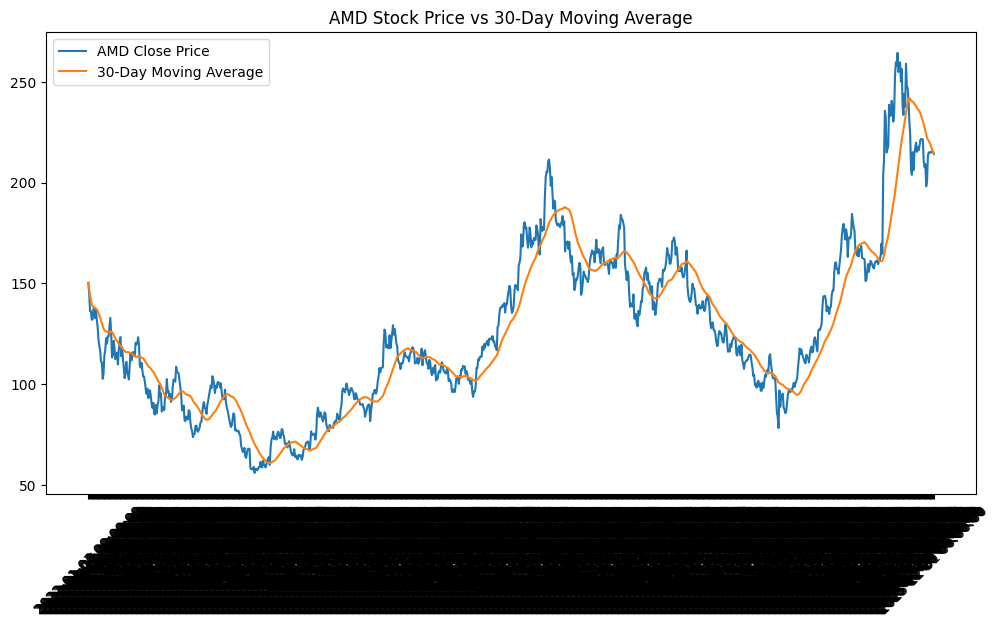

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(
    moving_avg["Date"],
    moving_avg["Close"],
    label="AMD Close Price"
)

plt.plot(
    moving_avg["Date"],
    moving_avg["moving_avg_30"],
    label="30-Day Moving Average"
)

plt.xticks(rotation=45)

plt.legend()

plt.title("AMD Stock Price vs 30-Day Moving Average")

plt.show()

In [14]:
sql_query = """
SELECT Date, Close
FROM amd_stock;
"""

with open("moving_average.sql", "w") as f:
    f.write(sql_query)

In [16]:
import pandas as pd

query = """
SELECT
    AVG(Close) AS avg_close_price
FROM amd_stock;
"""

pd.read_sql(query, conn)

,avg_close_price
0,126.047228


In [18]:
import pandas as pd

query = """
SELECT
    Date,
    Close,
    AVG(Close) OVER (
        ORDER BY Date
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ) AS moving_avg_30
FROM amd_stock;
"""

# Assuming 'conn' is the established SQLite connection object
df_moving_avg = pd.read_sql(query, conn)
df_moving_avg.head()

,Date,Close,moving_avg_30
0,2022-01-03 00:00:00,150.240005,150.240005
1,2022-01-04 00:00:00,144.419998,147.330002
2,2022-01-05 00:00:00,136.149994,143.603333
3,2022-01-06 00:00:00,136.229996,141.759998
4,2022-01-07 00:00:00,132.000000,139.807999


In [20]:
import pandas as pd

query = """
SELECT
    Date,
    Volume,
    AVG(Volume) OVER (
        ORDER BY Date
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ) AS avg_volume_30
FROM amd_stock;
"""

# Assuming 'conn' is the established SQLite connection object
df_avg_volume = pd.read_sql(query, conn)
df_avg_volume.head()

,Date,Volume,avg_volume_30
0,2022-01-03 00:00:00,59396600,5.939660e+07
1,2022-01-04 00:00:00,80200500,6.979855e+07
2,2022-01-05 00:00:00,65403200,6.833343e+07
3,2022-01-06 00:00:00,64802900,6.745080e+07
4,2022-01-07 00:00:00,58441100,6.564886e+07


In [22]:
sql_query_price_change = """
SELECT
    Date,
    Close,
    Open,
    (Close - Open) * 100.0 / Open AS Daily_Price_Change_Percent
FROM amd_stock;
"""

with open("price_change.sql", "w") as f:
    f.write(sql_query_price_change)

print("SQL query saved to price_change.sql")

SQL query saved to price_change.sql


In [24]:
import pandas as pd

query = """
SELECT
    Date,
    Close,
    LAG(Close) OVER (ORDER BY Date) AS prev_close,
    (Close - LAG(Close) OVER (ORDER BY Date)) AS price_change
FROM amd_stock;
"""

df_price_change = pd.read_sql(query, conn)
df_price_change.head()

,Date,Close,prev_close,price_change
0,2022-01-03 00:00:00,150.240005,NaN,NaN
1,2022-01-04 00:00:00,144.419998,150.240005,-5.820007
2,2022-01-05 00:00:00,136.149994,144.419998,-8.270004
3,2022-01-06 00:00:00,136.229996,136.149994,0.080002
4,2022-01-07 00:00:00,132.000000,136.229996,-4.229996


In [26]:
sql_query_average_price = """
SELECT
    AVG(Close) AS avg_close_price
FROM amd_stock;
"""

# Create the SQL file first, similar to previous examples
with open("average_price.sql", "w") as f:
    f.write(sql_query_average_price)

# Now, read and execute the query from the created file
with open("average_price.sql", "r") as f:
    query = f.read()

pd.read_sql(query, conn)

,avg_close_price
0,126.047228


In [28]:
with open("moving_average.sql", "r") as f:
    query = f.read()

df = pd.read_sql(query, conn)
df.head()

,Date,Close
0,2022-01-03 00:00:00,150.240005
1,2022-01-04 00:00:00,144.419998
2,2022-01-05 00:00:00,136.149994
3,2022-01-06 00:00:00,136.229996
4,2022-01-07 00:00:00,132.000000
